In [1]:
"""
============================================================
 02_model_training_max_accuracy.py
 Smart Waste Detection — Multi‑Model Experiment Framework
============================================================
This is the CORE notebook. It trains multiple pretrained backbones
with a two‑phase strategy (frozen head → full fine‑tune), compares
them, and saves the best model. Convert # %% blocks to Jupyter cells.

Priority: MAXIMUM CLASSIFICATION ACCURACY.
"""

'\n============================================================\n 02_model_training_max_accuracy.py\n Smart Waste Detection — Multi‑Model Experiment Framework\n============================================================\nThis is the CORE notebook. It trains multiple pretrained backbones\nwith a two‑phase strategy (frozen head → full fine‑tune), compares\nthem, and saves the best model. Convert # %% blocks to Jupyter cells.\n\nPriority: MAXIMUM CLASSIFICATION ACCURACY.\n'

In [3]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


# 🏆 02 — Model Training: Maximum Accuracy
Compare **ResNet18, ResNet50, EfficientNet‑B0, MobileNetV2,
DenseNet121, ConvNeXt‑Tiny** using a two‑phase training strategy:
1. Freeze backbone → train classifier head
2. Unfreeze → full fine‑tune with lower LR & cosine annealing

In [4]:
import sys, os
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()
sys.path.insert(0, current_dir)

import json
import pandas as pd
import torch

from config import (
    PATHS, CLASS_NAMES, NUM_CLASSES,
    TRAIN_DEFAULTS, EXPERIMENT_GRID, IMAGENET_MEAN, IMAGENET_STD,
)
from utils.dataset_utils import (
    set_seed, get_device, create_data_transforms,
    build_dataloaders, compute_class_weights,
)
from utils.training_utils import (
    create_model, count_parameters, freeze_backbone, unfreeze_model,
    train_model, run_experiment, save_experiment_results,
)
from utils.inference_utils import plot_training_curves

In [5]:
set_seed(TRAIN_DEFAULTS["seed"])
device = get_device()

[INFO] Random seed set to 42
[INFO] Using CPU


## 1. Data Pipeline

In [6]:
IMAGE_SIZE = 224
transforms_dict = create_data_transforms(IMAGE_SIZE, augment="standard")

In [7]:
loaders, dsets = build_dataloaders(
    PATHS["dataset"],
    transforms_dict,
    batch_size=TRAIN_DEFAULTS["batch_size"],
    num_workers=TRAIN_DEFAULTS["num_workers"],
    pin_memory=TRAIN_DEFAULTS["pin_memory"],
)

train_loader = loaders["train"]
val_loader   = loaders["val"]

print(f"\nClasses: {dsets['train'].classes}")
print(f"Num classes: {NUM_CLASSES}")

[INFO] train → 8,578 images, 268 batches
[INFO] val   → 1,833 images, 58 batches
[INFO] test  → 1,848 images, 58 batches

Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Num classes: 10


In [8]:
class_weights = compute_class_weights(dsets["train"])
class_weights = class_weights.to(device)

[INFO] Class weights: [1.6215500831604004, 1.7541922330856323, 0.8690983057022095, 0.6478852033615112, 0.70600825548172, 1.3176651000976562, 0.9174331426620483, 0.7679498791694641, 0.8459566235542297, 2.70599365234375]


## 2. Experiment Configuration
We run a grid of experiments across models, optimizers, and LRs.

In [9]:
MODELS = EXPERIMENT_GRID["models"]
OPTIMIZERS = EXPERIMENT_GRID["optimizers"]
LEARNING_RATES = EXPERIMENT_GRID["learning_rates"]

print("=" * 60)
print("EXPERIMENT GRID")
print("=" * 60)
print(f"Models      : {MODELS}")
print(f"Optimizers  : {OPTIMIZERS}")
print(f"LRs         : {LEARNING_RATES}")
total_runs = len(MODELS) * len(OPTIMIZERS) * len(LEARNING_RATES)
print(f"Total runs  : {total_runs}")
print("=" * 60)

EXPERIMENT GRID
Models      : ['resnet18', 'resnet50', 'efficientnet_b0', 'mobilenet_v2', 'densenet121', 'convnext_tiny']
Optimizers  : ['adamw']
LRs         : [0.0003, 0.0001]
Total runs  : 12


## 3. Run Experiments
Each experiment uses two‑phase training:
- **Phase 1**: frozen backbone, 5 epochs, 10× LR → train head quickly
- **Phase 2**: unfrozen, full epochs, cosine LR → fine‑tune everything


######################################################################
# EXPERIMENT: resnet18_lr0.0003_adamw
######################################################################

############################################################
# EXPERIMENT: resnet18 | LR=0.0003 | Opt=adamw
############################################################
[INFO] Created resnet18 via timm (pretrained=True)
[INFO] Backbone frozen; 'fc' unfrozen.

 Training: resnet18_lr0.0003_adamw_phase1
 Optimizer: adamw | LR: 0.0029999999999999996 | Epochs: 5



Epoch 1 [TRAIN]:   0%|          | 0/268 [00:00<?, ?it/s]c:\SDIS\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/5 │ Train Loss: 1.4547 Acc:  66.88% │ Val Loss: 1.2289 Acc:  76.70% │ LR: 3.00e-03
[INFO] Checkpoint saved → c:\SDIS\models\resnet18_lr0.0003_adamw_phase1_best.pth  (val_acc=76.70%)


Epoch   2/5 │ Train Loss: 1.1572 Acc:  77.55% │ Val Loss: 1.1576 Acc:  80.20% │ LR: 2.71e-03
[INFO] Checkpoint saved → c:\SDIS\models\resnet18_lr0.0003_adamw_phase1_best.pth  (val_acc=80.20%)


Epoch   3/5 │ Train Loss: 1.1100 Acc:  78.92% │ Val Loss: 1.1333 Acc:  81.45% │ LR: 1.96e-03
[INFO] Checkpoint saved → c:\SDIS\models\resnet18_lr0.0003_adamw_phase1_best.pth  (val_acc=81.45%)


...

Epoch  22/30 │ Train Loss: 0.6125 Acc:  99.88% │ Val Loss: 0.8103 Acc:  94.05% │ LR: 6.26e-05


Epoch  23/30 │ Train Loss: 0.6115 Acc:  99.87% │ Val Loss: 0.8100 Acc:  94.05% │ LR: 5.05e-05


Epoch  24/30 │ Train Loss: 0.6106 Acc:  99.87% │ Val Loss: 0.8095 Acc:  94.05% │ LR: 3.94e-05


Epoch  25/30 │ Train Loss: 0.6099 Acc:  99.92% │ Val Loss: 0.8096 Acc:  94.11% │ LR: 2.96e-05


Epoch  26/30 │ Train Loss: 0.6078 Acc:  99.98% │ Val Loss: 0.8097 Acc:  94.38% │ LR: 2.10e-05
[INFO] Early stopping triggered (patience=7).
[INFO] Stopping at epoch 26.

[INFO] Training complete in 492.3 min. Best val accuracy: 94.49%
[INFO] Training curves saved → c:\SDIS\outputs\curves_resnet18_lr0.0003_adamw.png


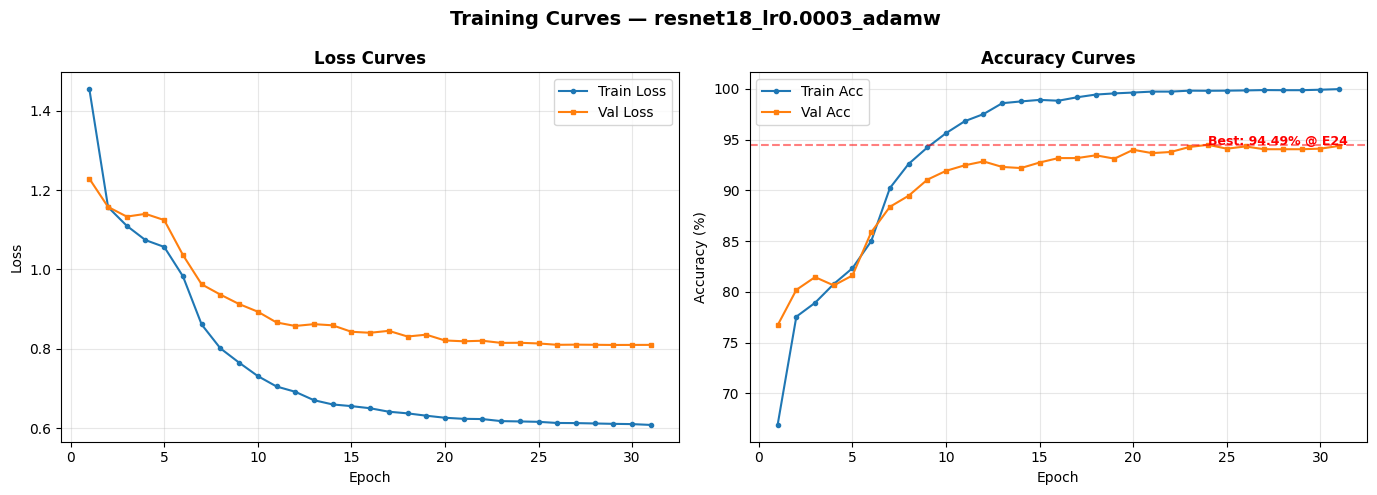


######################################################################
# EXPERIMENT: resnet18_lr0.0001_adamw
######################################################################

############################################################
# EXPERIMENT: resnet18 | LR=0.0001 | Opt=adamw
############################################################
[INFO] Created resnet18 via timm (pretrained=True)
[INFO] Backbone frozen; 'fc' unfrozen.

 Training: resnet18_lr0.0001_adamw_phase1
 Optimizer: adamw | LR: 0.001 | Epochs: 5



Epoch   1/5 │ Train Loss: 1.7599 Acc:  59.72% │ Val Loss: 1.4591 Acc:  71.25% │ LR: 1.00e-03
[INFO] Checkpoint saved → c:\SDIS\models\resnet18_lr0.0001_adamw_phase1_best.pth  (val_acc=71.25%)


Epoch   2/5 │ Train Loss: 1.3210 Acc:  73.81% │ Val Loss: 1.2860 Acc:  75.56% │ LR: 9.05e-04
[INFO] Checkpoint saved → c:\SDIS\models\resnet18_lr0.0001_adamw_phase1_best.pth  (val_acc=75.56%)


Epoch   3/5 │ Train Loss: 1.2199 Acc:  76.13% │ Val Loss: 1.2389 Acc:  77.52% │ LR: 6.55e-04
[INFO] Checkpoint saved → c:\SDIS\models\resnet18_lr0.0001_adamw_phase1_best.pth  (val_acc=77.52%)


Epoch   4/5 │ Train Loss: 1.1833 Acc:  77.16% │ Val Loss: 1.2056 Acc:  78.18% │ LR: 3.46e-04
[INFO] Checkpoint saved → c:\SDIS\models\resnet18_lr0.0001_adamw_phase1_best.pth  (val_acc=78.18%)


...

Epoch  15/30 │ Train Loss: 0.6894 Acc:  97.62% │ Val Loss: 0.8523 Acc:  93.24% │ LR: 5.57e-05
[INFO] Checkpoint saved → c:\SDIS\models\resnet18_lr0.0001_adamw_phase2_best.pth  (val_acc=93.24%)


Epoch  16/30 │ Train Loss: 0.6821 Acc:  98.05% │ Val Loss: 0.8529 Acc:  92.85% │ LR: 5.05e-05


Epoch  17/30 │ Train Loss: 0.6796 Acc:  98.06% │ Val Loss: 0.8492 Acc:  93.07% │ LR: 4.53e-05


Epoch  18/30 │ Train Loss: 0.6739 Acc:  98.17% │ Val Loss: 0.8443 Acc:  93.29% │ LR: 4.02e-05
[INFO] Checkpoint saved → c:\SDIS\models\resnet18_lr0.0001_adamw_phase2_best.pth  (val_acc=93.29%)


KeyboardInterrupt: 

In [10]:
all_results = []
best_overall_acc = 0.0
best_overall_model = None
best_overall_name = ""

PATHS["models"].mkdir(parents=True, exist_ok=True)
PATHS["outputs"].mkdir(parents=True, exist_ok=True)
PATHS["logs"].mkdir(parents=True, exist_ok=True)

for model_name in MODELS:
    for opt_name in OPTIMIZERS:
        for lr in LEARNING_RATES:
            tag = f"{model_name}_lr{lr}_{opt_name}"
            print(f"\n{'#' * 70}")
            print(f"# EXPERIMENT: {tag}")
            print(f"{'#' * 70}")

            try:
                model, history = run_experiment(
                    model_name=model_name,
                    num_classes=NUM_CLASSES,
                    train_loader=train_loader,
                    val_loader=val_loader,
                    device=device,
                    lr=lr,
                    optimizer_name=opt_name,
                    epochs=TRAIN_DEFAULTS["epochs"],
                    patience=TRAIN_DEFAULTS["patience"],
                    label_smoothing=TRAIN_DEFAULTS["label_smoothing"],
                    class_weights=class_weights,
                    save_dir=str(PATHS["models"]),
                    freeze_epochs=5,
                )

                # Record
                params = count_parameters(model)
                result = {
                    "model_name":   model_name,
                    "optimizer":    opt_name,
                    "lr_used":      lr,
                    "best_val_acc": history["best_val_acc"],
                    "total_time_s": history.get("total_time_s", 0),
                    "train_loss":   history["train_loss"],
                    "train_acc":    history["train_acc"],
                    "val_loss":     history["val_loss"],
                    "val_acc":      history["val_acc"],
                    "total_params": params["total"],
                    "trainable_params": params["trainable"],
                }
                all_results.append(result)

                # Training curves
                plot_training_curves(
                    history,
                    title=f"Training Curves — {tag}",
                    save_path=str(PATHS["outputs"] / f"curves_{tag}.png"),
                )

                # Track global best
                if history["best_val_acc"] > best_overall_acc:
                    best_overall_acc = history["best_val_acc"]
                    best_overall_model = model
                    best_overall_name = tag

                # Save per-experiment history
                hist_path = PATHS["logs"] / f"history_{tag}.json"
                with open(hist_path, "w") as f:
                    json.dump({k: v for k, v in history.items()
                               if isinstance(v, (list, float, int, str))}, f, indent=2)

            except Exception as e:
                print(f"[ERROR] Experiment {tag} failed: {e}")
                import traceback; traceback.print_exc()
                continue

## 4. Experiment Leaderboard

In [11]:
leaderboard_data = []
for r in all_results:
    leaderboard_data.append({
        "Model":         r["model_name"],
        "Optimizer":     r["optimizer"],
        "LR":            r["lr_used"],
        "Best Val Acc%": round(r["best_val_acc"], 2),
        "Time (min)":    round(r["total_time_s"] / 60, 1),
        "Params (M)":    round(r["total_params"] / 1e6, 1),
    })

df_leaderboard = pd.DataFrame(leaderboard_data)
df_leaderboard = df_leaderboard.sort_values("Best Val Acc%", ascending=False)
df_leaderboard = df_leaderboard.reset_index(drop=True)
df_leaderboard.index = df_leaderboard.index + 1  # 1‑indexed rank
df_leaderboard.index.name = "Rank"

print("\n" + "=" * 70)
print("                    EXPERIMENT LEADERBOARD")
print("=" * 70)
print(df_leaderboard.to_string())
print("=" * 70)

lb_path = PATHS["outputs"] / "experiment_leaderboard.csv"
df_leaderboard.to_csv(lb_path)
print(f"\n[INFO] Leaderboard saved → {lb_path}")


                    EXPERIMENT LEADERBOARD
         Model Optimizer      LR  Best Val Acc%  Time (min)  Params (M)
Rank                                                                   
1     resnet18     adamw  0.0003          94.49       530.2        11.2

[INFO] Leaderboard saved → c:\SDIS\outputs\experiment_leaderboard.csv


In [12]:
save_experiment_results(all_results, str(PATHS["experiment_csv"]))

[INFO] Experiment results saved → c:\SDIS\outputs\experiment_results.csv


## 5. Save Best Model

In [13]:
if best_overall_model is not None:
    best_path = PATHS["best_model"]
    torch.save({
        "model_state_dict": best_overall_model.state_dict(),
        "class_names": CLASS_NAMES,
        "num_classes": NUM_CLASSES,
        "model_tag": best_overall_name,
        "best_val_acc": best_overall_acc,
        "image_size": IMAGE_SIZE,
    }, best_path)
    print(f"\n🏆 BEST MODEL: {best_overall_name}")
    print(f"   Val Accuracy: {best_overall_acc:.2f}%")
    print(f"   Saved → {best_path}")

    # Also save a summary
    best_info = {
        "model_tag": best_overall_name,
        "best_val_acc": best_overall_acc,
        "model_path": str(best_path),
    }
    with open(PATHS["outputs"] / "best_model_info.json", "w") as f:
        json.dump(best_info, f, indent=2)
else:
    print("[WARN] No successful experiments — no model saved.")


🏆 BEST MODEL: resnet18_lr0.0003_adamw
   Val Accuracy: 94.49%
   Saved → c:\SDIS\models\best_waste_classifier.pth


## ✅ Training Complete
The best model has been saved. Proceed to
**03_model_evaluation_and_comparison.py** for detailed analysis.

print("\n" + "=" * 60)
print("  TRAINING COMPLETE — PROCEED TO EVALUATION")
print("=" * 60)